In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
# import style sheet 
plt.style.use('Hannes_TUD.mplstyle')

Bad value in file 'Hannes_TUD.mplstyle', line 17 ("axes.prop_cycle: cycler(color=['D20F41','7569BE', 'BC1589', 'D20F41', '#C85000', '7FC6FF', 'C8C8FF', 'FFBFFF', 'FBEB78', 'FFC700', '7C7A23', '007D4B', '0A777F', 'FFE4B3', 'D2DC46', '8CE6AB', '8CE6D7', '000000', 'FFFFFF', '323F48', '566371', '7D8894', 'A5AEB8', 'D0D5DC', 'E7E9ED'])"): Key axes.prop_cycle: "cycler(color=['D20F41','7569BE', 'BC1589', 'D20F41', '" is not a valid cycler construction: unterminated string literal (detected at line 1) (<unknown>, line 1)


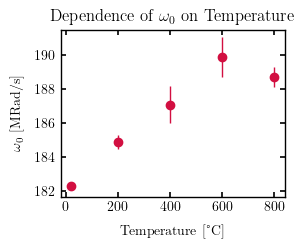

In [3]:
omega = np.array([182.3, 184.89, 187.1, 189.90, 188.72])

# corresponding uncertainties (±)
omega_err = np.array([0.19, 0.39, 1.10, 1.16, 0.61])
Te = [20,200,400,600,800]
# using the style sheet plot
fig, ay = plt.subplots(figsize=(2.89, 2.17))
ay.errorbar(Te, omega, yerr=omega_err, fmt='o', color='#D20F41')
ay.set_xlabel('Temperature [°C]')
ay.set_ylabel(r'$\omega_0$ [MRad/s]')
ay.set_title(r'Dependence of $\omega_0$ on Temperature')
# save figure
fig.savefig('omega_vs_Temperature.png', bbox_inches='tight', dpi =300)

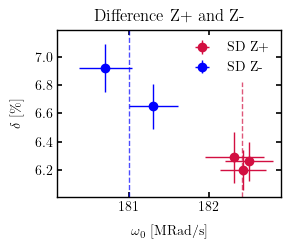

In [4]:
wpv = [182.31,182.5, 182.42 ]
wpe = [0.37,0.3,0.29]
wmv = [181.3,180.7]
wme = [0.31,0.33]
dpv = [6.29, 6.26, 6.20]
dpe = [0.18, 0.14, 0.14]
dmv = [6.65, 6.92]
dme = [0.16, 0.17]
# plot with error bars
fig, ax = plt.subplots(figsize=(2.89, 2.17))
# colors 'D20F41','7569BE' use only these colors
ax.errorbar(wpv, dpv, xerr=wpe, yerr=dpe, fmt='o', label='SD Z+', color='#D20F41')
ax.errorbar(wmv, dmv, xerr=wme, yerr=dme, fmt='o', label='SD Z-', color='blue')
ax.set_xlim(180.1, 182.9)
ax.set_ylim(6.01, 7.19)
# add vertical lines at average of wpv and wmv
# stop the red line at y=6.69
ax.axvline(np.mean(wpv), color='#D20F41', linestyle='--', alpha=0.7, ymax=0.69)
ax.axvline(np.mean(wmv), color='blue', linestyle='--', alpha=0.7)
# add horizontal lines at average of dpv and dmv
plt.legend()
# use latex for the labels
ax.set_xlabel(r'$\omega_0$ [MRad/s]')
ax.set_ylabel(r'$\delta$ [\%]')
ax.set_title('Difference Z+ and Z-')
# save the figure /Users/hannes/cernbox/Master_Thesis/Figures/ResultsC1
fig.savefig('omega_vs_delta.png', bbox_inches='tight', dpi=300)





In [5]:
import scipy.fftpack
def pacfft (x1,t, range, x2=None,maxt= 500):
    import numpy as np
    import scipy.fftpack
    import matplotlib.pyplot as plt
    import scipy.signal as signal
    import matplotlib.ticker as ticker

    """x1 data, t is time, range is the range of the data to be used for the Fourier transformation, x2 is the fit"""
    Mradfactor = 0.1592 #factor to conveert from Hz to Mrad
    k = len(x1) # len of array used to cut the data symmetrically
    # cut and mirroring the data at the y axis

    if x2 is not None:
        x1[0:2] = x2[0:2]
        x1mir  = np.flip(x1)
        tmir =  -np.flip(t)
        x1mir= np.append(x1mir,x1[1:])
        tmir = np.append(tmir,t[1:])



    x1 = np.array(x1mir)[k-range-1:k+range]
    t = np.array(tmir)[k-range-1:k+range]*10**-3 # 10^-3 for unit 

    # apply a window function to the data was in the thesis
    window = np.kaiser(len(x1), beta=20)
    # gauss window
    # use a different window function
    #window = np.hanning(len(x1))


    X1 = scipy.fftpack.fft(x1*window)
    # find the peaks in the Fourier transformation using signal 
    # calculate the x-axis. Using the periodicity of the data
    N = len(X1)       
    T = t[1]-t[0]
    f = np.linspace(0.0, 1.0/(2.0*T), N//2)
    # plot the Fourier transformation

    fig, ax = plt.subplots()
    ax.set_xlim(0, 1000)
    fy1 = 2.0/N * np.abs(X1[:N//2])
    ax.plot(f/Mradfactor, fy1, label = 'Data')
    ax.set_xlabel('Frequency [MHz]')
    ax.set_ylabel('Amplitude')
    ax.set_xlim(0,maxt)
    return ax

UnboundLocalError: cannot access local variable 'x1mir' where it is not associated with a value

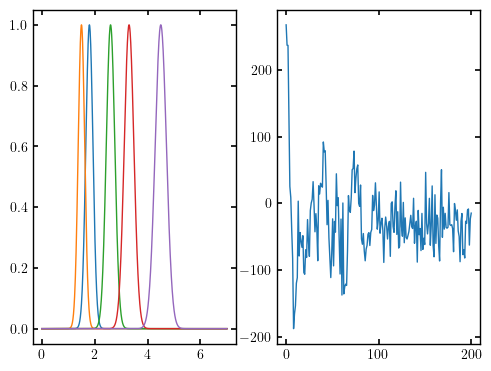

In [6]:
# create over a time of 10 12 fast oscillations supperposed 
d = [0.1]
for o in d:
    t = np.linspace(0, 200, 200)
    freqa = [1.80,1.5, 2.6, 3.3, 4.5]
    fa = np.linspace(0, 7, 1000)
    y = np.zeros_like(t)
    # 2 sublots 
    fig, ax = plt.subplots(1,2)
    def gauss(f, A, f0, sigma):
        return A * np.exp(-(f - f0)**2 / (2 * f0*sigma**2))
    for i in freqa:
        fik = gauss(fa, 1, i,o) 
        ax[0].plot(fa, fik)
        for j in range(len(fik)):
            y = y + np.cos(fa[j]*t/10)*fik[j]
    import random
    y = y + np.random.normal(-1, 1, size=len(t)) * y.max()*0.1
    ax[1].plot(t, y)
  
    pacfft(y, t, 500, maxt=1000)

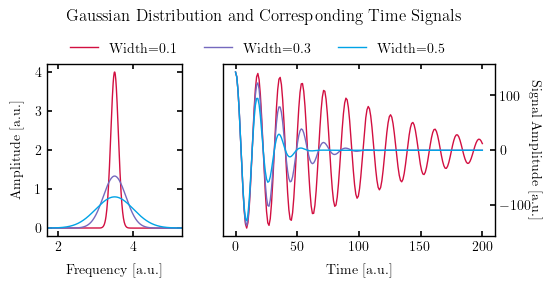

In [7]:
# create a function for a gaussian peak
def gaussian(x, A, x0, sigma):
    # all the gauss have the same volume of 1
    G  = A * np.exp(-(x - x0)**2 / (2 * sigma**2))
    G /= np.trapz(G, x)
    return G
# create a plot with multiple gaussian peaks with different withs add on the right handside the cosine of the frequencies in the peaks
fig, ax = plt.subplots(1, 2, figsize=(5.78, 2.6), gridspec_kw={'width_ratios': [1, 2]})
fig.subplots_adjust(top=0.77)
fa = np.linspace(0, 7, 1000)
widths = [0.1, 0.3, 0.5]
colors = ['#D20F41', '#7569BE', '#00A3E6']
for w, c in zip(widths, colors):
    peak = gaussian(fa, 1, 3.5, w)
    ax[0].plot(fa, peak, color=c, label=f'Width={w}')
    # create a time signal as the cosine of the frequencies in the peak
    t = np.linspace(0, 200, 200)
    y = np.zeros_like(t)
    for j in range(len(peak)):
        y = y + np.cos(fa[j]*t/10)*peak[j]
    ax[1].plot(t, y, color=c)
ax[0].set_xlabel('Frequency [a.u.]')
ax[0].set_ylabel('Amplitude [a.u.]')
ax[0].set_xlim(1.7, 5.3)
ax[0].legend()
ax[1].set_xlabel('Time [a.u.]')
ax[1].set_ylabel('Signal Amplitude [a.u.]')
# y axis label on the right side translate
ax[1].yaxis.set_label_position("right")
# rotate the y axis label
ax[1].yaxis.label.set_rotation(270)
ax[1].yaxis.tick_right()
# add the legend above the subplots
ax[0].legend(loc='upper center', bbox_to_anchor=(1.55, 1.2), ncol=3, frameon=False)

# add a supertitle
fig.suptitle('Gaussian Distribution and Corresponding Time Signals')
fig.savefig('gaussian_peaks_and_signals.png', bbox_inches='tight', dpi=300)